In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

In [46]:
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=1000,
    noise=0.03,
    random_state=42
)

In [47]:
df = pd.DataFrame(
    {
        "X1" : X[:, 0],
        "X2" : X[:, 1],
        "Label" : y
    }
)

df.head()

,X1,X2,Label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


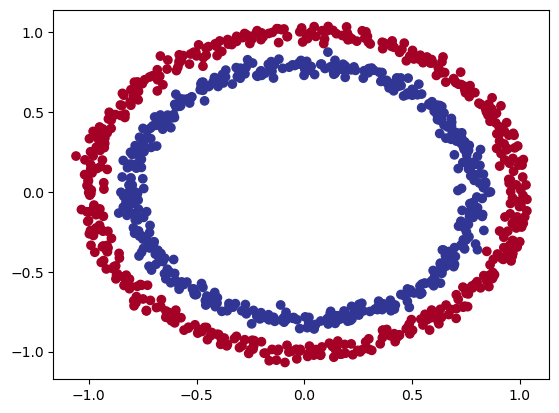

In [135]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c = y,
    cmap="RdYlBu"
)

In [117]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

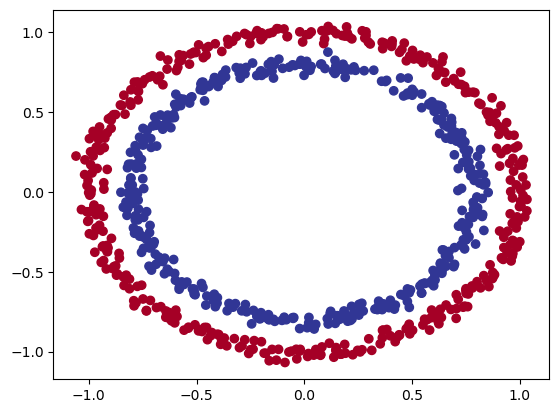

In [118]:
plt.scatter(
    x_train[:, 0],
    x_train[:, 1],
    c = y_train,
    cmap="RdYlBu"
)

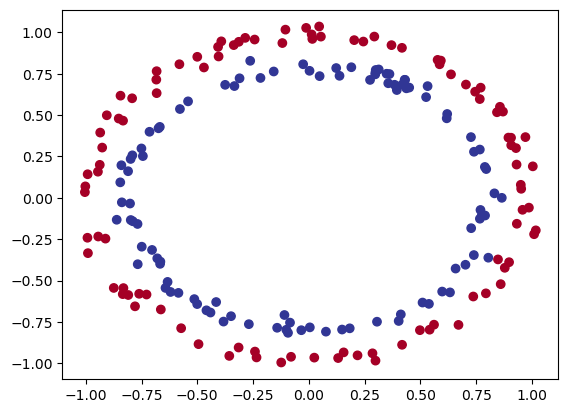

In [119]:
plt.scatter(
    x_test[:, 0],
    x_test[:, 1],
    c = y_test,
    cmap="RdYlBu"
)

In [120]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [121]:
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(
            in_features = 2,
            out_features=5
        )
        self.layer2 = nn.Linear(
            in_features = 5,
            out_features=1
        )

    def forward(self, x:torch.Tensor):
        return self.layer2(
            self.layer1(x)
        )

In [122]:
model = Classifier()

In [123]:
model.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.4861,  0.1682],
                      [ 0.1814,  0.1719],
                      [-0.0793,  0.6686],
                      [-0.5285, -0.6305],
                      [ 0.3613, -0.4124]])),
             ('layer1.bias',
              tensor([-0.5212,  0.1336, -0.6768, -0.2983,  0.3276])),
             ('layer2.weight',
              tensor([[ 0.1715, -0.2248, -0.0207, -0.4373, -0.2215]])),
             ('layer2.bias', tensor([0.4312]))])

### Simpler way of model instantiation

In [177]:
model = nn.Sequential(
    nn.Linear(
        in_features=2,
        out_features=4
    ),
    nn.Tanh(),
    nn.Linear(
        in_features=4,
        out_features=2
    ),
    nn.Tanh(),
    nn.Linear(
        in_features=2,
        out_features=1
    ),
)

In [178]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2970,  0.3086],
                      [-0.0613,  0.7057],
                      [ 0.4994, -0.3309],
                      [ 0.3566, -0.2584]])),
             ('0.bias', tensor([ 0.4149, -0.1092,  0.0715,  0.1270])),
             ('2.weight',
              tensor([[-0.4658,  0.2631,  0.1783,  0.2280],
                      [ 0.3864, -0.1010, -0.3095,  0.0824]])),
             ('2.bias', tensor([-0.2135,  0.0524])),
             ('4.weight', tensor([[ 0.1179, -0.4830]])),
             ('4.bias', tensor([0.4217]))])

In [179]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(
    params=model.parameters(),
    lr=0.03
)

In [182]:
epochs = 1000

training_loss = []
testing_loss = []

for epoch in range(epochs):
    model.train()

    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    training_loss.append(loss.item())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)
        testing_loss.append(test_loss.item())

    if epoch % 100 == 0:
        print(f"Epoch : {epoch} | Training Loss : {loss} | Testing Loss : {test_loss}")

    

Epoch : 0 | Training Loss : 0.6960689425468445 | Testing Loss : 0.6963034868240356
Epoch : 100 | Training Loss : 0.694770336151123 | Testing Loss : 0.6952397227287292
Epoch : 200 | Training Loss : 0.6944043040275574 | Testing Loss : 0.6949960589408875
Epoch : 300 | Training Loss : 0.694184422492981 | Testing Loss : 0.6948596239089966
Epoch : 400 | Training Loss : 0.6940181851387024 | Testing Loss : 0.6947581768035889
Epoch : 500 | Training Loss : 0.6938861608505249 | Testing Loss : 0.6946790814399719
Epoch : 600 | Training Loss : 0.6937789916992188 | Testing Loss : 0.6946162581443787
Epoch : 700 | Training Loss : 0.6936904788017273 | Testing Loss : 0.6945654153823853
Epoch : 800 | Training Loss : 0.6936162710189819 | Testing Loss : 0.6945234537124634
Epoch : 900 | Training Loss : 0.6935531497001648 | Testing Loss : 0.6944883465766907


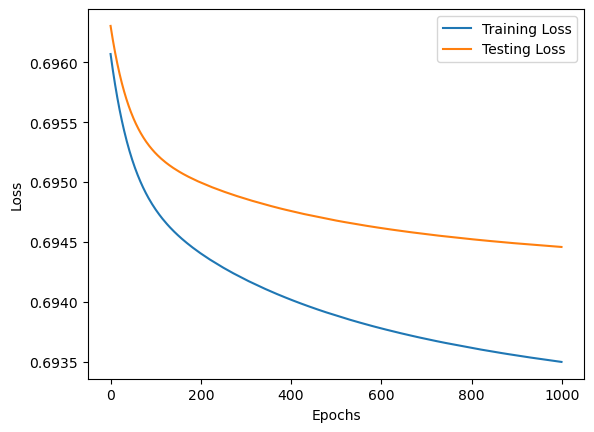

In [183]:
plt.plot(
    range(epochs),
    training_loss,
    label="Training Loss"
)
plt.plot(
    range(epochs),
    testing_loss,
    label="Testing Loss"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()